# EDA — Stores (Walmart Sales Forecast)

## Sección 1 — Análisis Exploratorio de Datos (EDA) de `stores.csv`

Este notebook cubre la primera etapa del proyecto: entender la estructura del dataset de tiendas (`stores.csv`), que contiene el identificador, tipo y tamaño de cada tienda Walmart. Es la base sobre la que luego se unirán `train.csv`, `test.csv` y `features.csv`.

> **Cómo usar este notebook:** ejecute las celdas en orden, de arriba hacia abajo. Cada bloque de código está precedido por una explicación de qué hace y por qué.

---
## Paso 0 — Carga del dataset

Se carga `stores.csv` desde `data/raw/` usando las rutas centralizadas en `walmart_sales_forecast.config`, en vez de rutas absolutas escritas a mano, para que el notebook funcione igual en cualquier máquina donde se clone el repositorio.

In [1]:
import sys
from pathlib import Path

# Permite importar walmart_sales_forecast al ejecutar desde notebooks/
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from walmart_sales_forecast.config import RAW_DATA_DIR

sns.set_style("whitegrid")

df = pd.read_csv(RAW_DATA_DIR / "stores.csv")
print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)
df.head()

2026-08-18 17:04:16.766 | INFO     | walmart_sales_forecast.config:<module>:11 - PROJ_ROOT path is: C:\Users\lucan\Desktop\Diplomado\Ciencias de datos\Modulo V\Laboratorios\laboratory\walmart_project


Dataset cargado correctamente.
Dimensiones: (45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


---
## 1.1 Inspección general

Se revisa la estructura del dataset: número de filas y columnas, tipos de datos, valores nulos y filas duplicadas.

Antes de cualquier análisis es necesario conocer el estado de los datos. `stores.csv` es pequeño (45 tiendas), por lo que cualquier anomalía debería ser fácil de detectar y corregir en esta etapa.

In [2]:
print("Dimensiones:", df.shape)
print("Valores nulos totales:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("IDs de tienda duplicados:", df["Store"].duplicated().sum())
print()
df.info()

Dimensiones: (45, 3)
Valores nulos totales: 0
Filas duplicadas: 0
IDs de tienda duplicados: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [3]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


---
## 1.2 Distribución del tipo de tienda (`Type`)

Se cuenta cuántas tiendas hay de cada tipo (A, B, C) y se grafica.

El tipo de tienda es una variable categórica que probablemente se relacione con el tamaño y el volumen de ventas — tiendas más grandes suelen clasificarse como tipo A. Entender su distribución ayuda a anticipar si habrá pocas observaciones para algún tipo.

Type
A    22
B    17
C     6
Name: count, dtype: int64

Porcentaje por tipo:
Type
A    48.9
B    37.8
C    13.3
Name: proportion, dtype: float64


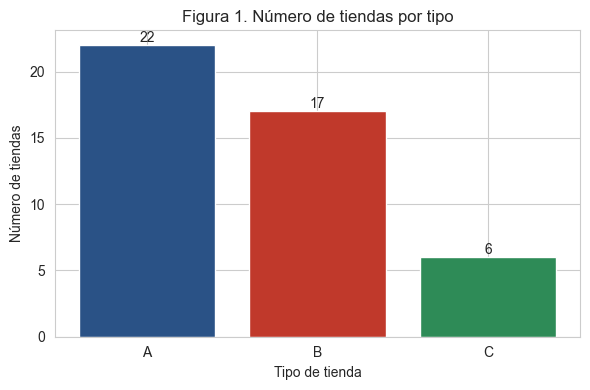

In [4]:
conteo_tipo = df["Type"].value_counts().sort_index()
print(conteo_tipo)
print("\nPorcentaje por tipo:")
print((df["Type"].value_counts(normalize=True).sort_index() * 100).round(1))

plt.figure(figsize=(6, 4))
plt.bar(conteo_tipo.index, conteo_tipo.values, color=["#2a5286", "#c0392b", "#2e8b57"])
plt.title("Figura 1. Número de tiendas por tipo")
plt.xlabel("Tipo de tienda")
plt.ylabel("Número de tiendas")
for i, v in enumerate(conteo_tipo.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

---
## 1.3 Distribución del tamaño de tienda (`Size`)

Se grafica la distribución de `Size` (superficie de la tienda) de forma general.

Permite ver si hay tiendas atípicamente grandes o pequeñas antes de analizarlas por tipo.

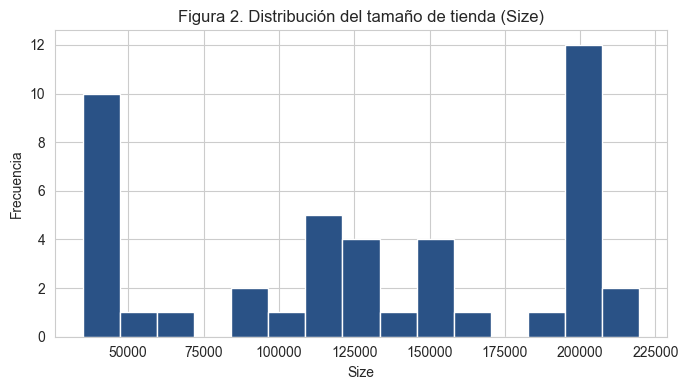

count        45.000000
mean     130287.600000
std       63825.271991
min       34875.000000
25%       70713.000000
50%      126512.000000
75%      202307.000000
max      219622.000000
Name: Size, dtype: float64


In [5]:
plt.figure(figsize=(7, 4))
plt.hist(df["Size"], bins=15, color="#2a5286")
plt.title("Figura 2. Distribución del tamaño de tienda (Size)")
plt.xlabel("Size")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(df["Size"].describe())

---
## 1.4 Tamaño de tienda según el tipo

Se comparan los tamaños de tienda entre los tres tipos (A, B, C) mediante diagramas de caja.

Esto confirma (o refuta) la hipótesis de que el tipo de tienda está asociado a su tamaño, lo cual es relevante porque `Type` y `Size` se usarán más adelante como variables al unir con `train.csv`/`test.csv` para predecir ventas.

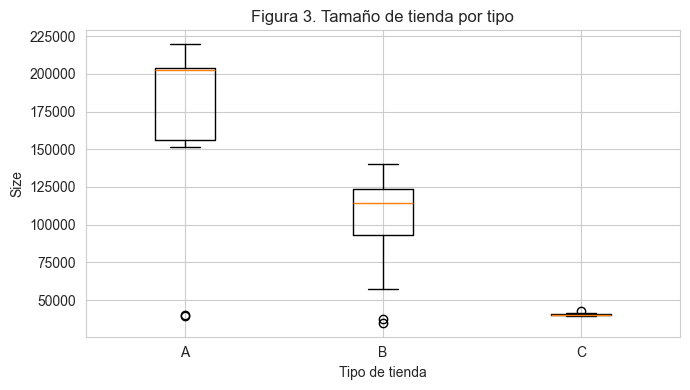

      count           mean           std      min        25%       50%  \
Type                                                                     
A      22.0  177247.727273  49392.621098  39690.0  155840.75  202406.0   
B      17.0  101190.705882  32371.137916  34875.0   93188.00  114533.0   
C       6.0   40541.666667   1304.145033  39690.0   39745.00   39910.0   

           75%       max  
Type                      
A     203819.0  219622.0  
B     123737.0  140167.0  
C      40774.0   42988.0  


In [6]:
plt.figure(figsize=(7, 4))
orden_tipos = sorted(df["Type"].unique())
data = [df[df["Type"] == t]["Size"] for t in orden_tipos]
plt.boxplot(data, tick_labels=orden_tipos)
plt.title("Figura 3. Tamaño de tienda por tipo")
plt.xlabel("Tipo de tienda")
plt.ylabel("Size")
plt.tight_layout()
plt.show()

print(df.groupby("Type")["Size"].describe())

---
## Resumen

**Hallazgos de esta sección (a completar/confirmar con los valores obtenidos al ejecutar):**

1. `stores.csv` tiene 45 filas (una por tienda) y 3 columnas: `Store`, `Type`, `Size`. Sin valores nulos ni filas duplicadas esperadas, dado el tamaño reducido del dataset.
2. Las tiendas se agrupan en 3 tipos (A, B, C), con una distribución desigual entre ellos.
3. El tamaño (`Size`) varía notablemente según el tipo de tienda: se espera que el tipo A concentre las tiendas más grandes y el tipo C las más pequeñas.

Estos hallazgos informan cómo tratar `Type` y `Size` como variables (por ejemplo, codificación de `Type`) en la siguiente etapa (`walmart_sales_forecast/dataset.py`), donde `stores.csv` se unirá con `train.csv`/`test.csv` y `features.csv`.